In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

**Go to files and Upload netflix.csv to session storage**

In [ ]:
df=pd.read_csv('netflix.csv')
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


**1. Problem Statement and Analysing basic metrics**

---


 Netflix wants actionable, data-driven recommendations about content production and which type of shows/movies to produce and how to grow the business, mainly focusing on below points:


*   Content type (Movies vs TV Shows) -
    What types of content (Movie vs TV Show) are dominating the platform?

*   Regional/country-specific demand and opportunity -
    What are the key countries and creators driving content volume

*   Trends in content, actors, and directors

*   Content genre and duration patterns -
    How has content production evolved over time, particularly the focus on Movies vs. TV Shows?




     



**Analysing basic metrics**

---

*   Total no. of shows : 8807
*   Total Columns: 12
*   Type Split:
    1.   Movies: 6131 (69.6%)
    2.   TV Shows: 2676 (30.4%)


      
      









  


In [ ]:
df.shape

(8807, 12)

In [ ]:
print(f"Total Rows: {df.shape[0]}")

Total Rows: 8807


In [ ]:
print(f"Total Columns: {df.shape[1]}")

Total Columns: 12


In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB
None


In [ ]:
print(f"Type Split:\n{df['type'].value_counts()}")

Type Split:
type
Movie      6131
TV Show    2676
Name: count, dtype: int64


**2. Observations on Data Shape, Types, Missing Values, Summary**

---



*   Shape of Data (Rows, Columns): (8807, 12)
*   All columns are of object type except release_year which is of int type.




*   Columns: director, cast, country, date_added, raiting, duration have missing values


*   Highest missing vaue is in director column with 2634 Null Count.






*   Statistical Summary (release_year):
    1. Mean Release Year: 2014
    2. Min Release Year: 1925
    3. Max Release Year: 2021
    4. 75th Percentile: 2019



*   Observation: The majority of the content on Netflix (75%) was originally released in the year 2019 or below.












In [ ]:
print("\nShape of Data (Rows, Columns):", df.shape)


Shape of Data (Rows, Columns): (8807, 12)


In [ ]:
print(df.dtypes)

show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object


***Converting to appropriate data types***

In [ ]:
# removing the leading and trailing spaces from the column date_added
df['date_added']=df['date_added'].str.strip()

In [ ]:
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

In [ ]:
print(df.isnull().sum())

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64


In [ ]:
df['release_year'] = df['release_year'].astype('int')

In [ ]:
df['type'] = df['type'].astype('category')

In [ ]:
# checking the data types of columns after making required changes
print(df.dtypes)

show_id                 object
type                  category
title                   object
director                object
cast                    object
country                 object
date_added      datetime64[ns]
release_year             int64
rating                  object
duration                object
listed_in               object
description             object
dtype: object


As per above Code, We can see the column data type has been changed:

    1.   date_added has been changed to datetime datatype.
    2.   type has been changed to category.



***Missing Value Detection***

In [ ]:
print("\nMissing Value Count:")
print(df.isnull().sum())


Missing Value Count:
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64


***Statistical Summary***

In [ ]:
# Statistical Summary (only for numerical columns)
print("\nStatistical Summary (release_year):")
print(df['release_year'].describe())


Statistical Summary (release_year):
count    8807.000000
mean     2014.180198
std         8.819312
min      1925.000000
25%      2013.000000
50%      2017.000000
75%      2019.000000
max      2021.000000
Name: release_year, dtype: float64


**Pre-processing the data for Analysis (Missing Value Treatment)**

In [ ]:
#rating has 4 NaN rows in the dataframe.
df[df['rating'].isnull()]


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
5989,s5990,Movie,13TH: A Conversation with Oprah Winfrey & Ava ...,NaN,"Oprah Winfrey, Ava DuVernay",NaN,2017-01-26,2017,NaN,37 min,Movies,Oprah Winfrey sits down with director Ava DuVe...
6827,s6828,TV Show,Gargantia on the Verdurous Planet,NaN,"Kaito Ishikawa, Hisako Kanemoto, Ai Kayano, Ka...",Japan,2016-12-01,2013,NaN,1 Season,"Anime Series, International TV Shows","After falling through a wormhole, a space-dwel..."
7312,s7313,TV Show,Little Lunch,NaN,"Flynn Curry, Olivia Deeble, Madison Lu, Oisín ...",Australia,2018-02-01,2015,NaN,1 Season,"Kids' TV, TV Comedies","Adopting a child's perspective, this show take..."
7537,s7538,Movie,My Honor Was Loyalty,Alessandro Pepe,"Leone Frisa, Paolo Vaccarino, Francesco Miglio...",Italy,2017-03-01,2015,NaN,115 min,Dramas,"Amid the chaos and horror of World War II, a c..."


In [ ]:
df['rating'].mode()

,rating
0,TV-MA


In [ ]:
# Filling 'rating' NaN with the mode
df['rating'] = df['rating'].fillna(df['rating'].mode()[0])

In [ ]:
df['date_added'].isnull().sum()

np.int64(10)

In [ ]:
# Filling the 10 missing values of 'date_added' with the mode of the date_added column.
df['date_added'] = df['date_added'].fillna(df['date_added'].mode()[0])

In [ ]:
# Checking NaN records in duration column.
df[df['duration'].isnull()]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
5541,s5542,Movie,Louis C.K. 2017,Louis C.K.,Louis C.K.,United States,2017-04-04,2017,74 min,NaN,Movies,"Louis C.K. muses on religion, eternal love, gi..."
5794,s5795,Movie,Louis C.K.: Hilarious,Louis C.K.,Louis C.K.,United States,2016-09-16,2010,84 min,NaN,Movies,Emmy-winning comedy writer Louis C.K. brings h...
5813,s5814,Movie,Louis C.K.: Live at the Comedy Store,Louis C.K.,Louis C.K.,United States,2016-08-15,2015,66 min,NaN,Movies,The comic puts his trademark hilarious/thought...


In [ ]:
# filling Nan records of 'duartion' column with mode of duration.
df['duration'] = df['duration'].fillna(df['duration'].mode()[0])

In [ ]:
# Filling 'director','cast' and 'country' columns with 'Unknown'
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')

**Observation Table of Data Frame**

---

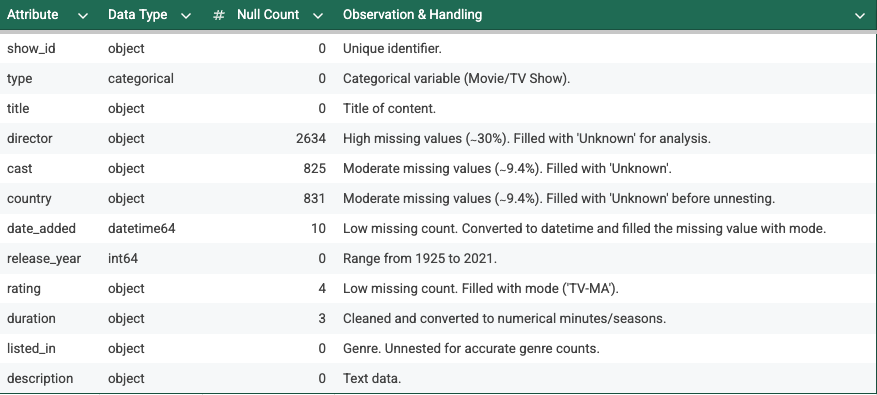

***Checking info of dataframe after handling Null Values.***


---

Now, the columns which were having the missing values have been handled properly.

In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8807 non-null   object        
 1   type          8807 non-null   category      
 2   title         8807 non-null   object        
 3   director      8807 non-null   object        
 4   cast          8807 non-null   object        
 5   country       8807 non-null   object        
 6   date_added    8807 non-null   datetime64[ns]
 7   release_year  8807 non-null   int64         
 8   rating        8807 non-null   object        
 9   duration      8807 non-null   object        
 10  listed_in     8807 non-null   object        
 11  description   8807 non-null   object        
dtypes: category(1), datetime64[ns](1), int64(1), object(9)
memory usage: 765.7+ KB
None


**Unnesting Multi-Value Columns**

In [ ]:
# Function for Unnesting Multi-Value Columns
def unnest_col(df, column_name, separator=','):

  # Handling NaN values by 'Unknown' before splitting
  if column_name in ['director', 'cast', 'country', 'listed_in']:
    df[column_name] = df[column_name].fillna('Unknown')

  # Split the column by separator & striping whitespace
  s = df[column_name].str.strip().str.split(separator).apply(pd.Series, 1).stack()
  s.index = s.index.droplevel(-1)
  s.name = column_name

  # Droping original column and joining the unnested series
  del df[column_name]
  df = df.join(s)

  # Striping any remaining whitespace in the unnested values
  df[column_name] = df[column_name].str.strip()
  return df



*Unnesting the Data (Required for Visual Analysis)*

In [ ]:
# creating a copy of df
df1 = df.copy()

In [ ]:
df1.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [ ]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8807 non-null   object        
 1   type          8807 non-null   category      
 2   title         8807 non-null   object        
 3   director      8807 non-null   object        
 4   cast          8807 non-null   object        
 5   country       8807 non-null   object        
 6   date_added    8807 non-null   datetime64[ns]
 7   release_year  8807 non-null   int64         
 8   rating        8807 non-null   object        
 9   duration      8807 non-null   object        
 10  listed_in     8807 non-null   object        
 11  description   8807 non-null   object        
dtypes: category(1), datetime64[ns](1), int64(1), object(9)
memory usage: 765.7+ KB


In [ ]:
# Unnest Country
df_country = unnest_col(df1, 'country')

# Unnest Genres (Listed_in)
df_genres = unnest_col(df1, 'listed_in')

# Unnest Directors
df_director = unnest_col(df1, 'director')

# Unnest Cast (Actors)
df_cast = unnest_col(df1, 'cast')

/tmp/ipython-input-4029723357.py:9: FutureWarning: the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.
  s = df[column_name].str.strip().str.split(separator).apply(pd.Series, 1).stack()
/tmp/ipython-input-4029723357.py:9: FutureWarning: the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.
  s = df[column_name].str.strip().str.split(separator).apply(pd.Series, 1).stack()
/tmp/ipython-input-4029723357.py:9: FutureWarning: the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.
  s = df[column_name].str.strip().str.split(separator).apply(pd.Series, 1).stack()
/tmp/ipython-input-4029723357.py:9: FutureWarning: the convert_dtype parameter is deprecated and will be remo

**3. Non-Graphical Analysis: Value counts and unique attributes**

---



In [ ]:
# Most Frequent Countries (After Unnesting, excluding 'Unknown')
top_countries = df_country[df_country['country'] != 'Unknown']['country'].value_counts().head(10)
print("\nTop 10 Content Producing Countries :")
print(top_countries)


Top 10 Content Producing Countries :
country
United States     3690
India             1046
United Kingdom     806
Canada             445
France             393
Japan              318
Spain              232
South Korea        231
Germany            226
Mexico             169
Name: count, dtype: int64


In [ ]:
# Total Unique Countries
df_country['country'].nunique()

124

In [ ]:
# Most Frequent Genres (After Unnesting)
top_genres = df_genres['listed_in'].value_counts().head(10)
print("\nTop 10 Genres:")
print(top_genres)


Top 10 Genres:
listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64


In [ ]:
# Total Unique Genres
df_genres['listed_in'].nunique()

42

In [ ]:
# Most Frequent Director (After Unnesting, excluding 'Unknown')
top_directors = df_director[df_director['director'] != 'Unknown']['director'].value_counts().head(10)
print("\nTop 10 Directors (by content count):")
print(top_directors)


Top 10 Directors (by content count):
director
Rajiv Chilaka          22
Jan Suter              21
Raúl Campos            19
Suhas Kadav            16
Marcus Raboy           16
Jay Karas              15
Cathy Garcia-Molina    13
Martin Scorsese        12
Youssef Chahine        12
Jay Chapman            12
Name: count, dtype: int64


In [ ]:
# Total Unique Directors
df_director['director'].nunique()

4994

In [ ]:
# Most Frequent Cast Member (After Unnesting, excluding 'Unknown')
top_cast = df_cast[df_cast['cast'] != 'Unknown']['cast'].value_counts().head(10)
print("\nTop 10 Cast Members (by content count):")
print(top_cast)


Top 10 Cast Members (by content count):
cast
Anupam Kher         43
Shah Rukh Khan      35
Julie Tejwani       33
Takahiro Sakurai    32
Naseeruddin Shah    32
Rupa Bhimani        31
Om Puri             30
Akshay Kumar        30
Yuki Kaji           29
Amitabh Bachchan    28
Name: count, dtype: int64


In [ ]:
# Total Unique Actors
df_cast['cast'].nunique()

36440

In [ ]:
# Most common Movie Duration (Univariate)
top_movie_durations = df1[df1['type'] == 'Movie']['duration'].value_counts().head(5)
print("\nTop 5 Movie Durations:")
print(top_movie_durations)


Top 5 Movie Durations:
duration
90 min    152
94 min    146
97 min    146
93 min    146
91 min    144
Name: count, dtype: int64


In [ ]:
# Most common TV Show Duration (Univariate)
top_tv_show_durations = df1[df1['type'] == 'TV Show']['duration'].value_counts().head(5)
print("\nTop 5 TV Show Durations:")
print(top_tv_show_durations)


Top 5 TV Show Durations:
duration
1 Season     1793
2 Seasons     425
3 Seasons     199
4 Seasons      95
5 Seasons      65
Name: count, dtype: int64


**4. Visual Analysis (Univariate, Bivariate)**

---

*Univariate Analysis*

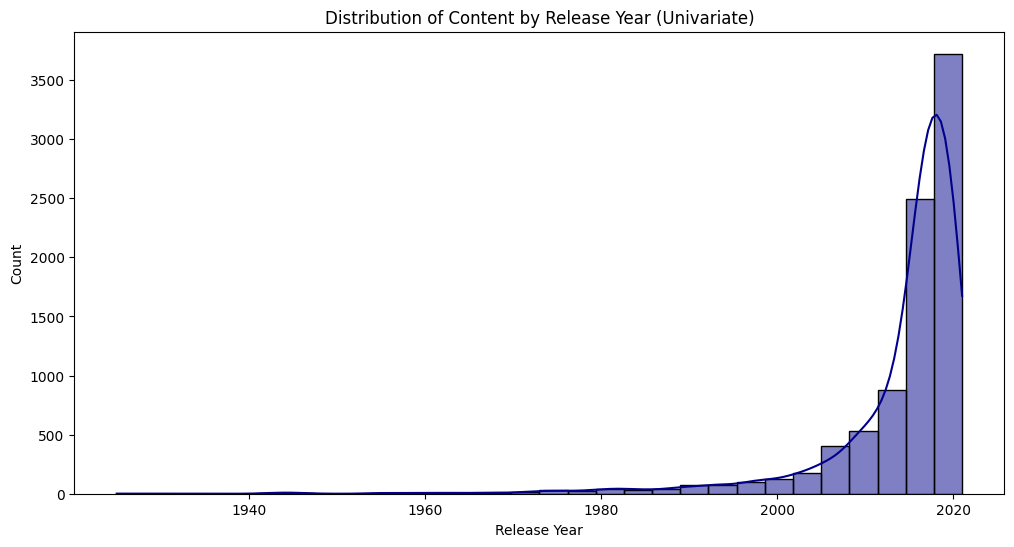

In [ ]:
# 4.1. Univariate Analysis (Continuous/Discrete: Release Year)
plt.figure(figsize=(12, 6))
sns.histplot(df['release_year'], kde=True, bins=30, color='darkblue')
plt.title('Distribution of Content by Release Year (Univariate)')
plt.xlabel('Release Year')
plt.ylabel('Count')
plt.show()

**Observation:**
1. The distribution is heavily skewed toward recent years, peaking sharply between 2017 and 2019.
2. The count of titles released before 2000 is minimal, reaffirming the focus on modern content.

/tmp/ipython-input-1422322671.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='type', data=df, palette='Set2')


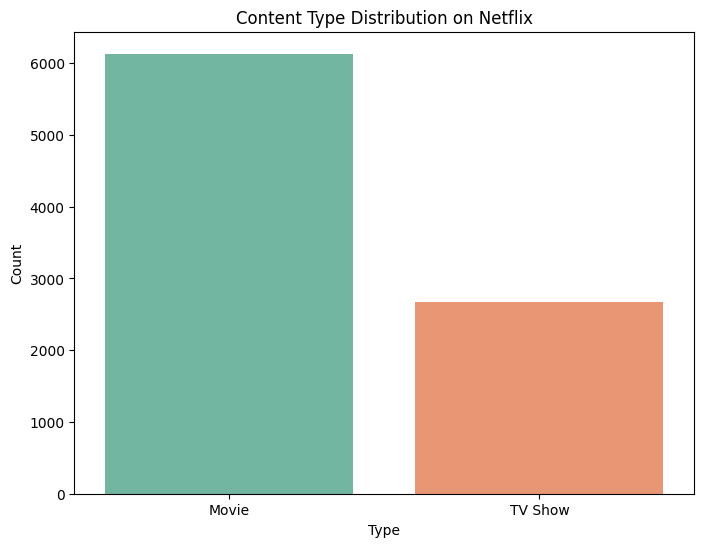

In [ ]:
# 4.2. Univariate Analysis (Categorical: Type)
plt.figure(figsize=(8, 6))
sns.countplot(x='type', data=df, palette='Set2')
plt.title('Content Type Distribution on Netflix')
plt.xlabel('Type')
plt.ylabel('Count')
plt.show()

In [ ]:
df['type'].value_counts(normalize=True)

,proportion
type,
Movie,0.696151
TV Show,0.303849


**Observation:**
1. The catalogue is heavily skewed towards Movies (∼70%) compared to TV Shows (∼30%).
2. This shows Majority of Content type on Netflix is Movie.

*Bivariate Analysis*

In [ ]:
# 4.3. Bivariate Analysis: Content Production over Time (Trend Analysis)
df1['added_year'] = df1['date_added'].dt.year
content_by_year_type = df1.groupby(['added_year', 'type']).size().unstack(fill_value=0)

/tmp/ipython-input-10180621.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  content_by_year_type = df1.groupby(['added_year', 'type']).size().unstack(fill_value=0)


In [ ]:
content_by_year_type

type,Movie,TV Show
added_year,,
2008,1,1
2009,2,0
2010,1,0
2011,13,0
2012,3,0
2013,6,5
2014,19,5
2015,56,26
2016,253,176


<Figure size 1200x600 with 0 Axes>

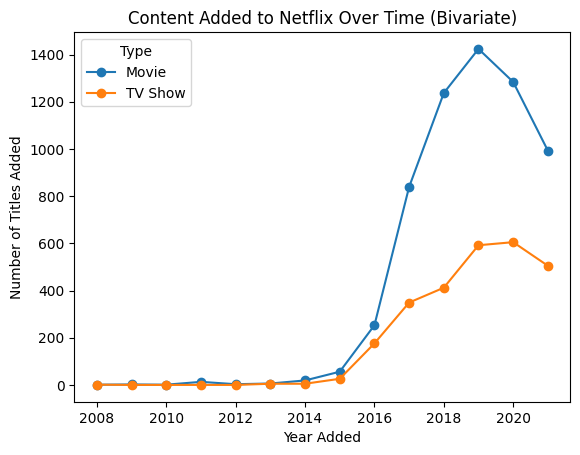

In [ ]:
plt.figure(figsize=(12, 6))
content_by_year_type.plot(kind='line', marker='o')
plt.title('Content Added to Netflix Over Time (Bivariate)')
plt.xlabel('Year Added')
plt.ylabel('Number of Titles Added')
plt.legend(title='Type')
plt.show()

**Observation:**
1. Content added over Netflix exploded between 2016 and 2019, peaking in 2019. This massive growth was driven primarily by Movies.
2. Post 2019, the rate of new Movie additions has decreased, while TV Show additions have remained high or relatively steady, suggesting a recent strategic shift toward building out recurring TV content.

In [ ]:
# 4.4. Bivariate Analysis: Top 10 Countries by Content Type (Unnested Data)
country_type_counts = df_country[df_country['country'] != 'Unknown'].groupby('country')['type'].value_counts().unstack(fill_value=0)
top_countries_overall = df_country[df_country['country'] != 'Unknown']['country'].value_counts().head(10).index
country_type_counts = country_type_counts.loc[top_countries_overall]

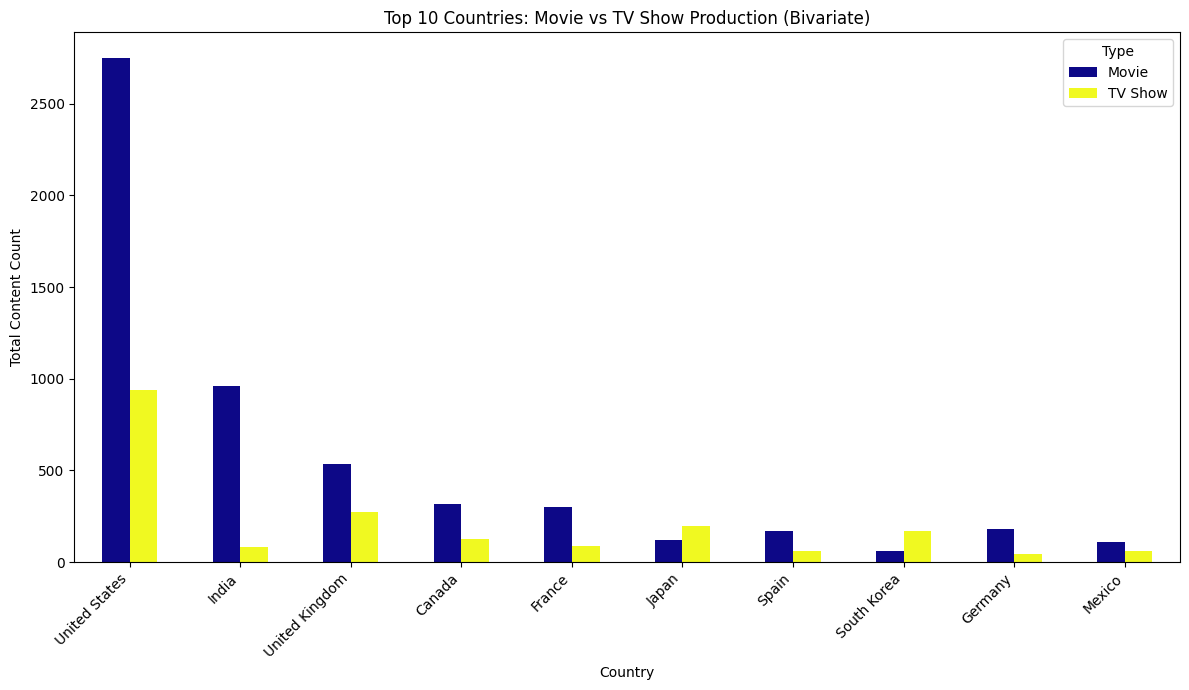

In [ ]:
country_type_counts.plot(kind='bar', figsize=(12, 7), colormap='plasma')
plt.title('Top 10 Countries: Movie vs TV Show Production (Bivariate)')
plt.xlabel('Country')
plt.ylabel('Total Content Count')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Type')
plt.tight_layout()
plt.show()

**Observation:**

1. United States is the production leader, producing both the most Movies and the most TV Shows.

2. India is the second-largest content contributor, but it's production is heavily dominated by Movies, with a minimal contribution of TV Shows.

3. Other major contributors are UK, Canada, France.

In [ ]:
# 4.5. Bivariate Analysis: Genre vs. Content Type (Unnested Data)
genre_type_counts = df_genres.groupby('listed_in')['type'].value_counts().unstack(fill_value=0)
# Select top 10 genres (overall) for plotting
top_genres_overall = df_genres['listed_in'].value_counts().head(10).index
genre_type_counts = genre_type_counts.loc[top_genres_overall]

In [ ]:
genre_type_counts

type,Movie,TV Show
listed_in,,
International Movies,2752,0
Dramas,2427,0
Comedies,1674,0
International TV Shows,0,1351
Documentaries,869,0
Action & Adventure,859,0
TV Dramas,0,763
Independent Movies,756,0
Children & Family Movies,641,0


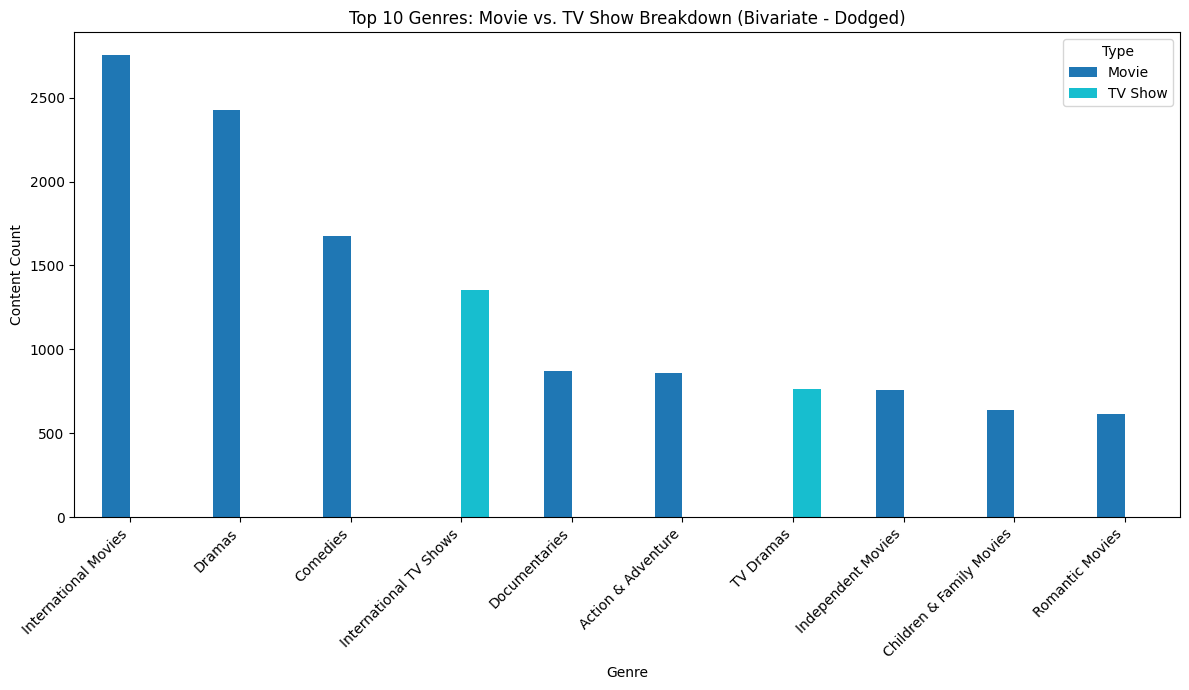

In [ ]:
genre_type_counts.plot(kind='bar', figsize=(12, 7), colormap='tab10')
plt.title('Top 10 Genres: Movie vs. TV Show Breakdown (Bivariate - Dodged)')
plt.xlabel('Genre')
plt.ylabel('Content Count')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Type')
plt.tight_layout()
plt.show()

**Observation:**

1. Genres like International Movies, Dramas, and Comedies are predominantly Movies.

2. Genres like International TV Shows, TV Dramas, and Kids' TV are naturally dominated by TV Shows.

3. Dramas is the most versatile category, ranking high for both Movies and TV Shows.

In [ ]:
# 4.6. Continuous Variable Analysis (Movie Duration Distribution)
df_movies = df1[df1['type'] == 'Movie']
df_movies.drop(df_movies[df_movies['duration']=='1 Season'].index, inplace=True)
df_movies['duration_minutes']=df_movies['duration'].str.replace(' min','').astype(int)

/tmp/ipython-input-3933641915.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_movies.drop(df_movies[df_movies['duration']=='1 Season'].index, inplace=True)
/tmp/ipython-input-3933641915.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_movies['duration_minutes']=df_movies['duration'].str.replace(' min','').astype(int)


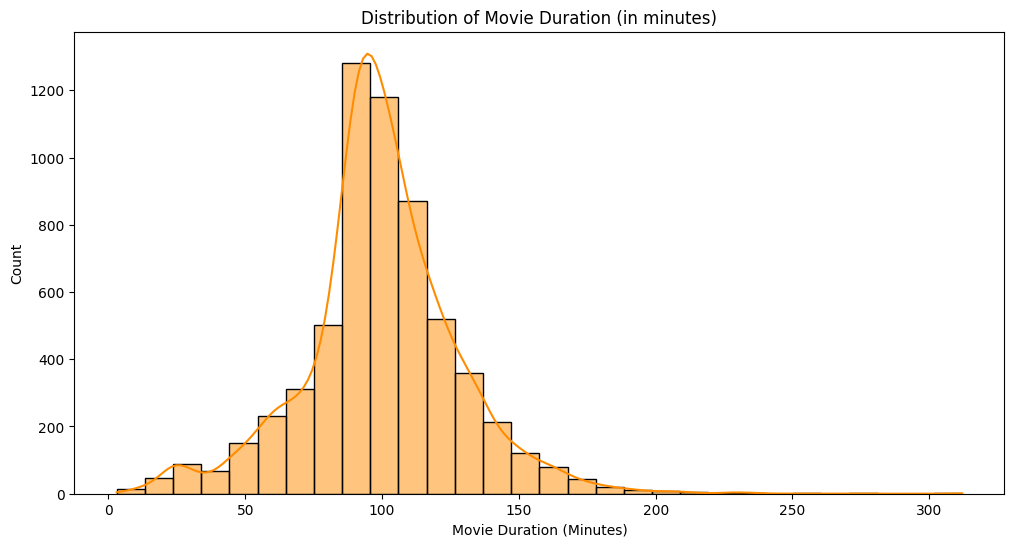

In [ ]:
plt.figure(figsize=(12, 6))
sns.histplot(df_movies['duration_minutes'], kde=True, bins=30, color='darkorange')
plt.title('Distribution of Movie Duration (in minutes)')
plt.xlabel('Movie Duration (Minutes)')
plt.ylabel('Count')
plt.show()

**Observation:**

1. The distribution of movie durations forms a strong normal-like curve.

2. The peak concentration is between 90 and 100 minutes.

3. The vast majority of movies fall within the 80 to 120-minute range.

In [ ]:
#4.7. Content Added on Netflix Month-wise (Univariate)
df1['added_month_name'] = df1['date_added'].dt.month_name()

/tmp/ipython-input-270518623.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df1['added_month_name'],data=df1, order=df1['added_month_name'].value_counts().index, palette='Set2')


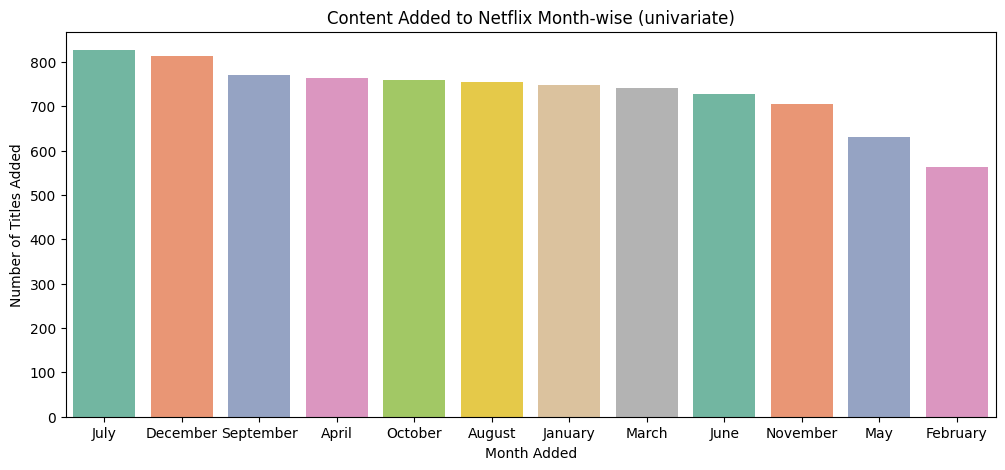

In [ ]:
plt.figure(figsize=(12, 5))
sns.countplot(x=df1['added_month_name'],data=df1, order=df1['added_month_name'].value_counts().index, palette='Set2')
plt.title('Content Added to Netflix Month-wise (univariate)')
plt.xlabel('Month Added')
plt.ylabel('Number of Titles Added')
plt.show()

**Observation:**
1. Highest number of new titles added in the month of July followed by December.
2. Least number of content were added in the month of Feb and May.

***Description Column - Words with Maximum Frequency***

---
Checking the most frequent word in Netflix dataset from Description of Titles.


In [ ]:
from wordcloud import WordCloud, STOPWORDS
text = " ".join(i for i in df1['description'].astype(str).dropna())
stopwords = set(STOPWORDS)
wordcloud = WordCloud(
        stopwords=stopwords,
        background_color='white',
        width=800,
        height=400,
        max_words=100, # Limit the number of words
        collocations=False # Disable showing common word pairs
    ).generate(text)
word_frequencies = wordcloud.words_
print(word_frequencies)

{'life': 1.0, 'new': 0.8662721893491124, 'young': 0.8627218934911243, 'find': 0.7739644970414201, 'family': 0.7514792899408284, 'friend': 0.7384615384615385, 'world': 0.6994082840236686, 'love': 0.6615384615384615, 'man': 0.6366863905325444, 's': 0.6153846153846154, 'take': 0.6094674556213018, 'two': 0.5976331360946746, 'woman': 0.5751479289940828, 'year': 0.5751479289940828, 'one': 0.4816568047337278, 'live': 0.47455621301775147, 'must': 0.4710059171597633, 'series': 0.46745562130177515, 'documentary': 0.4319526627218935, 'become': 0.4272189349112426, 'school': 0.4106508875739645, 'help': 0.39644970414201186, 'home': 0.3952662721893491, 'father': 0.37988165680473374, 'old': 0.37041420118343193, 'high': 0.36923076923076925, 'three': 0.3562130177514793, 'girl': 0.3301775147928994, 'group': 0.32781065088757394, 'secret': 0.3254437869822485, 'teen': 0.32189349112426036, 'team': 0.32189349112426036, 'set': 0.3088757396449704, 'student': 0.2923076923076923, 'make': 0.28994082840236685, 'bac

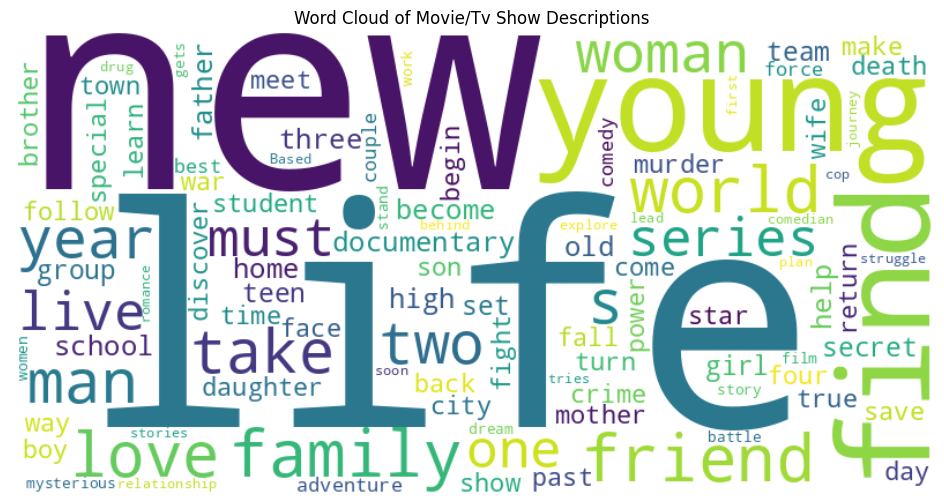

In [ ]:
plt.figure(figsize=(15, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off') # Hide axes
plt.title('Word Cloud of Movie/Tv Show Descriptions')
plt.show()

**Observation:**

As per WordCloud Graph most frequent word in description is **life** followed by **new** & **young**.

**5. Missing Value & Outlier check (Treatment)**

---
Columns and corresponding Missing value Observations as checked and treated in the above code earlier.

**Missing Values:**

The highest missing values are in Director (∼30%), followed by Cast and Country (∼9.4% each).

This missing information implies a loss of regional/creator data for a significant portion of the catalogue.

**Treatment:**

We filled these with 'Unknown' to prevent data loss and ensure the titles are still included in counts.

*Attaching the table of columns with their missing values and their corresponding treatment.*

---


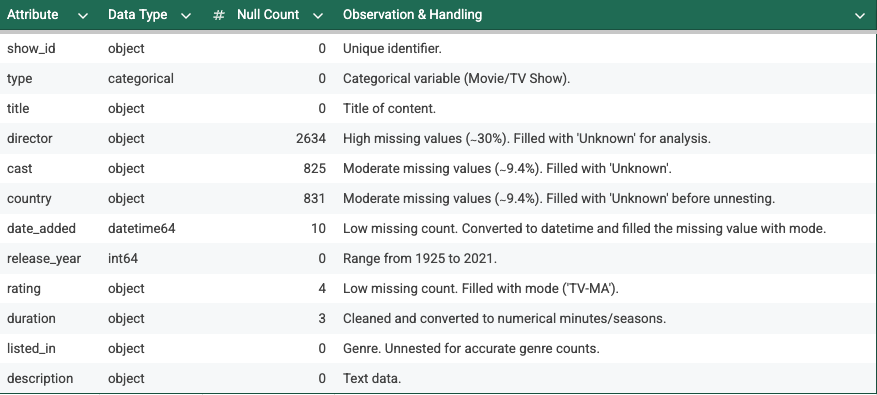


**Checking Outliers in columns**

**Outliers (Release Year):**

We can see in below grapgh that there are outliers for content released in the year (1925 to 2000).

These are valid data points representing historical classics or archive footage and should not be treated as errors, but rather as niche catalogue fillers.

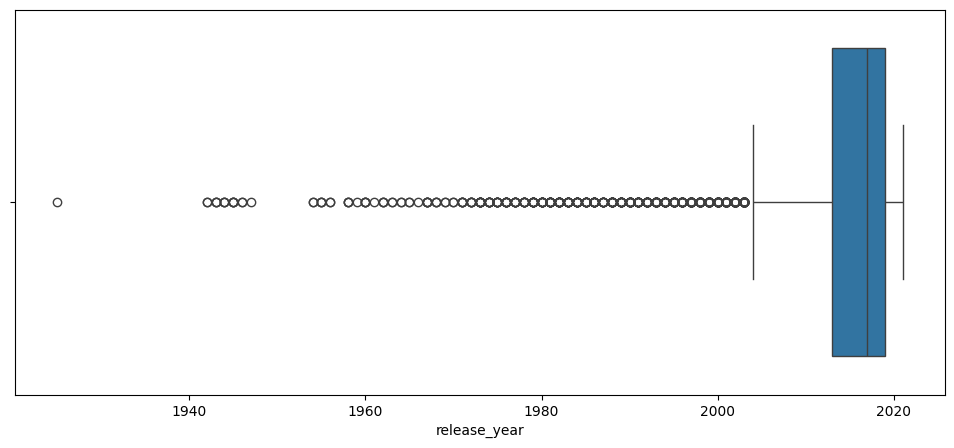

In [ ]:
plt.figure(figsize=(12, 5))
sns.boxplot(data=df1, x='release_year')
plt.show()

**Outliers (Movie Duration):**

The below grapgh clearly shows very few films under 40 minutes or over 160 minutes.

These outliers are valid i.e (short documentaries or epics) and require no treatment, but the business should focus production on the median range.

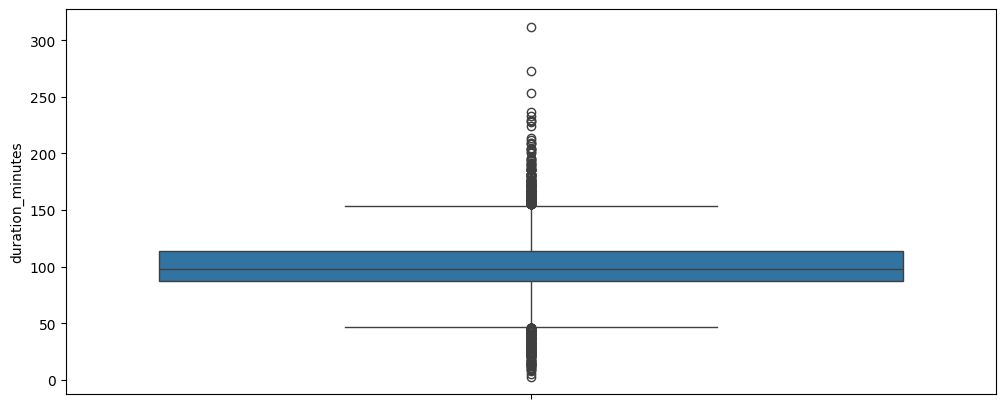

In [ ]:
plt.figure(figsize=(12, 5))
sns.boxplot(df_movies['duration_minutes'])
plt.show()

**6. Insights based on Non-Graphical and Visual Analysis**

---



*6.1 Comments on the range of attributes*

---



As per above observations on all the attributes:
  1. show_id : Unique Identifier
  2. type : Categorical variable (Movie/TV Show)
  3. title : Identifies and provides a summary of the content
  4. release_year : Range from 1925 to 2021
  5. duration : For movies, it's no. of minutes. For TV shows, it's the no. of seasons.


*6.2 Comments on the distribution of the variables and relationship between them*

---


* Movie vs TV Show volume is disproportionate (70% : 30%), but the acquisition trend shows a recent convergence, with Movie acquisition declining post-2019 and TV Show acquisition remaining robust, confirming a strategic shift toward Tv series.
* There is a global content imbalance: United States content is balanced between Movies and TV Shows, while the second largest market (India) is inclined heavily towards Movie

*  The majority of content is modern (released post-2010), suggesting content acquisition strategy prioritizes fresh content.
*   Content is highly concentrated in the United States, indicating a potential over reliance on a single market for production volume.



*6.3 Comments for each univariate and bivariate plot*

---


*   **Release Year Histogram:** The distribution is heavily skewed toward recent years, peaking sharply between 2017 and 2019. The count of titles released before 2000 is minimal, reaffirming the focus on modern content.

*   **Content Type Countplot:** The catalogue is heavily skewed towards Movies (∼70%) compared to TV Shows (∼30%). This shows Majority of Content type on Netflix is Movie.

* **Content Added on Netflix Trend:**  Content added over Netflix exploded between 2016 and 2019, peaking in 2019. This massive growth was driven primarily by Movies. Post 2019, the rate of new Movie additions has decreased, while TV Show additions have remained high or relatively steady, suggesting a recent strategic shift toward building out recurring TV content.

*   **Top Country Production Bar Graph:** Highlights the overwhelming US dominance and the strategic need to diversify production capacity, especially in high-volume regions like India, to include more TV Shows.
United States is the production leader, producing both the most Movies and the most TV Shows. India is the second-largest content contributor, but it's production is heavily dominated by Movies, with a minimal contribution of TV Shows.

*   **Genre Breakdown Bar Graph:** Confirms International Movies, Dramas, and Comedies as the three largest content buckets. Genres like International Movies, Dramas, and Comedies are predominantly Movies and
Genres like International TV Shows, TV Dramas are dominated by TV Shows.

* **Movie Duration Histogram:** The vast majority of movies fall within the 80 to 120-minute range. Provides a target production window of 90-100 minutes for maximum market acceptance.






**7. Business Insights** : *From above Non-Graphical and Visual Analysis*

---


*   Content peaking sharply between 2017 and 2019. The count of titles released before 2000 is minimal, reaffirming that the focus is on modern content.

*   TV Shows grew faster after 2018, while Movie additions plateaued slightly indicates that Netflix strategy has shifted toward TV Shows in recent years, aligning with the subscription-driven retention model.

*   Strategic Shift: Netflix has successfully executed a shift from high-volume, single-use content (Movies) to high-retention, serialized content (TV Shows) since 2020. This aligns with a subscription-based model that values sustained user engagement.

*   Best time to launch (month analysis): Netflix tends to add the most titles around year July and December which likely to capture: Summer viewing demand in many markets (school breaks, leisure time). Pre-holiday engagement spikes before major global streaming competition.

*   Market Imbalance & Opportunity (India): As per the graphical analysis, India is a massive source of content, but almost entirely in the Movie format. This represents a significant untapped opportunity to develop Indian-produced TV Shows to drive deeper engagement in that high-growth market.

*   Top Genres: The most common genre categories on the platform are International Movies, Dramas, and Comedies as analyzed from the above grapgh. Producers should be prioritiz in these areas, particularly focusing on International Movies.


*   Optimal Movie Length: The market preference is strongly focused on movies that are between 80 and 120 minutes. Deviating from this range may limit market adoption.

*  Most Frequent Directors are Rajiv Chilaka and Jan Suter. Most Frequent Cast Members are Anupam Kher and Shah Rukh Khan.

















**8. Recommendations**

---


*   Produce "TV Show in India" Initiative: Launch a focused initiative to commission 5-10 major TV show productions in India across popular local genres. This directly addresses the content imbalance in the second-largest content market and aligns with the global shift towards TV show growth.

*   Netflix can use subscribers data to find countries  rising subscriber growth and then Produce 8 to 10 local originals movies and tv shows each year to capture market share and subscriber interest.

*   Launch timing: Netflix can use the added_month_name distribution to plan major launches in months where Netflix historically adds many titles to capture increased viewer attention.

*   Target International TV Drama: As per above analysis the high volume of International Movies and the general popularity of Dramas, Netflix need to prioritize non-US International TV Dramas to secure globally appealing series content and diversify the supply chain away from US reliance.

*  Netflix can also identify genres that are popular globally but underrepresented in specific countries and then it can commission localized content in those genres.

* Standardize Movie Duration: Set a hard target for new movie commissions to fall within the 90-100 minute range, as this is the optimal and most accepted viewing duration this will help in minimizing production risk for new titles.

* Acknowledge & Retain High-Volume Creators: Engage the top directors and cast (the top 10 identified in the analysis) in exclusive deals, particularly those who work in the popular International/Drama/Comedy categories, to secure consistent content supply.

